

# Підготовка даних до аналізу






<h2>Мета</h2>

Ознайомитись з методикою первинної обробки даних. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати структуру завантажених даних
* Виправляти формати даних
* Знаходити та заповнювати пропуски в даних
* Знаходити викиди та некоректні значення
* Будувати прості візуалізації




<a name="task"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>





1. Скачати дані із файлу <a href="https://drive.google.com/file/d/1Vz4Kkbu4HVMuBKsOz_5gq3C8jYYXA89d/view?usp=drive_link" target="_blank">'Data2.csv'</a>. Записати дані у dataframe. Дослідити структуру даних.
2. Виправити помилки в даних.
3. Заповнити пропуски.
4. Додати стовпчик із щільністю населення.
5. Побудувати діаграми розмаху та гістограми.


<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити структуру даних</p>
</div>


Зчитую дані з файлу у датафрейм


In [11]:
import pandas as pd
import matplotlib.pylab as plt

filename = "Data2.csv"
df = pd.read_csv(filename, sep=';', encoding='cp1252')

In [59]:
df

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,Afghanistan,South Asia,"561,7787463",34656032.0,"9809,225",652860
1,Albania,Europe & Central Asia,"4124,98239",2876101.0,"5716,853",28750
2,Algeria,Middle East & North Africa,"3916,881571",40606052.0,"145400,217",2381740
3,American Samoa,East Asia & Pacific,"11834,74523",55599.0,NaN,200
4,Andorra,Europe & Central Asia,"36988,62203",77281.0,"462,042",470
...,...,...,...,...,...,...
212,Virgin Islands (U.S.),Latin America & Caribbean,NaN,102951.0,NaN,350
213,West Bank and Gaza,Middle East & North Africa,"2943,404534",4551566.0,NaN,6020
214,"Yemen, Rep.",Middle East & North Africa,"990,334774",27584213.0,"22698,73",527970
215,Zambia,Sub-Saharan Africa,"1269,573537",16591390.0,"4503,076",752610


<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
DATA_PATH = 'data/Data2.csv'

# Зчитуємо файл із заданим розділяючим символом ";"
df = pd.read_csv(DATA_PATH, sep=';')

'''
Зауваження: попередній код зчитування з файлу підходить для
файлів з кодуванням utf-8. Проте файл Data2.csv спочатку мав інше
кодування. Дане кодування потрібно вказати в якості параметру:
    
'''

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')


```
</details>




Досліджую структуру даних


In [21]:
df.describe(include = "all")

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
count,217,217,190,2.160000e+02,205,217
unique,217,7,190,NaN,202,213
top,Afghanistan,Europe & Central Asia,"561,7787463",NaN,"6318,241",460
freq,1,58,1,NaN,2,3
mean,NaN,NaN,NaN,3.432256e+07,NaN,NaN
std,NaN,NaN,NaN,1.347600e+08,NaN,NaN
min,NaN,NaN,NaN,1.109700e+04,NaN,NaN
25%,NaN,NaN,NaN,7.900265e+05,NaN,NaN
50%,NaN,NaN,NaN,6.221590e+06,NaN,NaN
75%,NaN,NaN,NaN,2.350337e+07,NaN,NaN


In [35]:
missing_data = df.isnull()
missing_data.head(5)
#"True" означає відсутнє значення, а "False" означає, що значення присутнє в наборі даних.

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,True,False
4,False,False,False,False,False,False


In [37]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

Country Name
Country Name
False    217
Name: count, dtype: int64

Region
Region
False    217
Name: count, dtype: int64

GDP per capita
GDP per capita
False    190
True      27
Name: count, dtype: int64

Populatiion
Populatiion
False    216
True       1
Name: count, dtype: int64

CO2 emission
CO2 emission
False    205
True      12
Name: count, dtype: int64

Area
Area
False    217
Name: count, dtype: int64



In [41]:
df.dtypes

Country Name       object
Region             object
GDP per capita     object
Populatiion       float64
CO2 emission       object
Area               object
dtype: object

Перевірка на відʼємність:

In [93]:
numeric_columns = ['GDP per capita', 'Populatiion', 'CO2 emission', 'Area']
negative_values = (df[numeric_columns] < 0).any()
negative_values

GDP per capita     True
Populatiion       False
CO2 emission      False
Area               True
dtype: bool

Отже, відʼємні значення зустрічаються в "GDP per capita" і "Area".

Бачу наступні проблеми в даних:
1. Формати даних, деякі стовпці мають неправильний тип даних ("GDP per capita", "CO2 emission", "Area").
2. Відʼємні значення ("GDP per capita", "Area").
3. Неправильна назва стовпця ("Populatiion").
4. Є пропущені значення в ознаках "GDP per capita", "Populatiion", "CO2 emission".


<a name="task2"></a> <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2"> Завдання  #2: </h2>

<p>Виправити помилки в даних</p>
</div>


<b>Проблема 1. Формати даних</b>
<p>
    Для виправлення форматів даних використаю метод <code>astype()</code>. Таким чином зміню тип даних стовпців "GDP per capita", "CO2 emission", "Area" з object на float. Але перед цим змінюю коми на крапки.</p>
</p>

In [ ]:
df['GDP per capita'] = df['GDP per capita'].str.replace(',', '.').astype(float)

In [74]:
df['CO2 emission'] = df['CO2 emission'].str.replace(',', '.').astype(float)

In [76]:
df['Area'] = df['Area'].str.replace(',', '.').astype(float)

Перевіряємо типи стовпців після перетворення.

In [82]:
df.dtypes

Country Name       object
Region             object
GDP per capita    float64
Populatiion       float64
CO2 emission      float64
Area              float64
dtype: object

<b>Проблема 2. Відʼємні значення</b>
<p>
    Для виправлення можна використати метод abs().
</p>

In [107]:
df[numeric_columns] = df[numeric_columns].abs()

Перевіряємо відсутність відʼємних значень:

In [105]:
negative_values = (df[numeric_columns] < 0).any()
negative_values

GDP per capita    False
Populatiion       False
CO2 emission      False
Area              False
dtype: bool

<b>Проблема 3. Неправильна назва стовпця</b>
<p>
    Для виправлення змінюємо назву стовпця "Populatiion".
</p>

In [117]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df.rename(columns={'Populatiion':'Population'}, inplace=True)
df

,Country Name,Region,GDP per capita,Population,CO2 emission,Area
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,NaN,200.0
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0
...,...,...,...,...,...,...
212,Virgin Islands (U.S.),Latin America & Caribbean,NaN,102951.0,NaN,350.0
213,West Bank and Gaza,Middle East & North Africa,2943.404534,4551566.0,NaN,6020.0
214,"Yemen, Rep.",Middle East & North Africa,990.334774,27584213.0,22698.730,527970.0
215,Zambia,Sub-Saharan Africa,1269.573537,16591390.0,4503.076,752610.0


<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3"> Завдання  #3: </h2>

<p>Заповнити пропуски</p>
</div>


Заповнювати пропуски для ознак "GDP per capita" і "CO2 emission" буду заміною на середнє значення, оскільки видалити їх не можемо (таких значень немало) і використати моду теж не можемо, бо нема такого значення, яке буде переважати.

Обчислення середнього значення для "GDP per capita":

In [126]:
avg_gdp = df['GDP per capita'].astype('float').mean(axis=0)
avg_gdp

13445.593416057367

Заповнюємо пропуски для "GDP per capita":

In [134]:
import numpy as np

df.replace({'GDP per capita':np.nan}, avg_gdp, inplace=True)

Обчислення середнього значення для "CO2 emission":

In [137]:
avg_co2 = df['CO2 emission'].astype('float').mean(axis=0)
avg_co2

165114.1163365854

Заповнюємо пропуски для "CO2 emission":

In [140]:
df.replace({'CO2 emission':np.nan}, avg_gdp, inplace=True)

Заповнювати пропуски для ознаки "Population" буду завдяки пошуку в інтернеті значення, оскільки в цьому стовпчику відсутнє лише одне значення і для нього не треба виконувати ніяких розрахунків.

Для початку знайдемо рядок з пропуском:

In [145]:
df[df['Population'].isnull()]

,Country Name,Region,GDP per capita,Population,CO2 emission,Area
61,Eritrea,Sub-Saharan Africa,13445.593416,NaN,696.73,117600.0


Заповнюємо пропуск:

In [151]:
df['Population'].fillna(3800146, inplace=True)

Досліджую структуру даних, чи всі пропуски заповнено


In [157]:
missing_data = df.isnull()

for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

Country Name
Country Name
False    217
Name: count, dtype: int64

Region
Region
False    217
Name: count, dtype: int64

GDP per capita
GDP per capita
False    217
Name: count, dtype: int64

Population
Population
False    217
Name: count, dtype: int64

CO2 emission
CO2 emission
False    217
Name: count, dtype: int64

Area
Area
False    217
Name: count, dtype: int64



 <a name="task4"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4"> Завдання  #4: </h2>

<p>Додати стовпчик із щільністю населення</p>
</div>


Щільність населення розраховується за формулою: Population / Area. Результати додаються до стовпчика "population density".

In [163]:
df['population density'] = df['Population'] / df['Area']
df

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225000,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853000,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217000,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,13445.593416,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042000,470.0,164.427660
...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),Latin America & Caribbean,13445.593416,102951.0,13445.593416,350.0,294.145714
213,West Bank and Gaza,Middle East & North Africa,2943.404534,4551566.0,13445.593416,6020.0,756.074086
214,"Yemen, Rep.",Middle East & North Africa,990.334774,27584213.0,22698.730000,527970.0,52.245796
215,Zambia,Sub-Saharan Africa,1269.573537,16591390.0,4503.076000,752610.0,22.045136


<a name="task5"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5"> Завдання  #5: </h2>

<p>Побудувати діаграми розмаху та гістограми</p>
</div>


Для побудови графіків скористайтесь бібліотекою Matplotlib. Спробуйте погратись з кольорами, розмірами та підписами.


Діаграми розмаху:

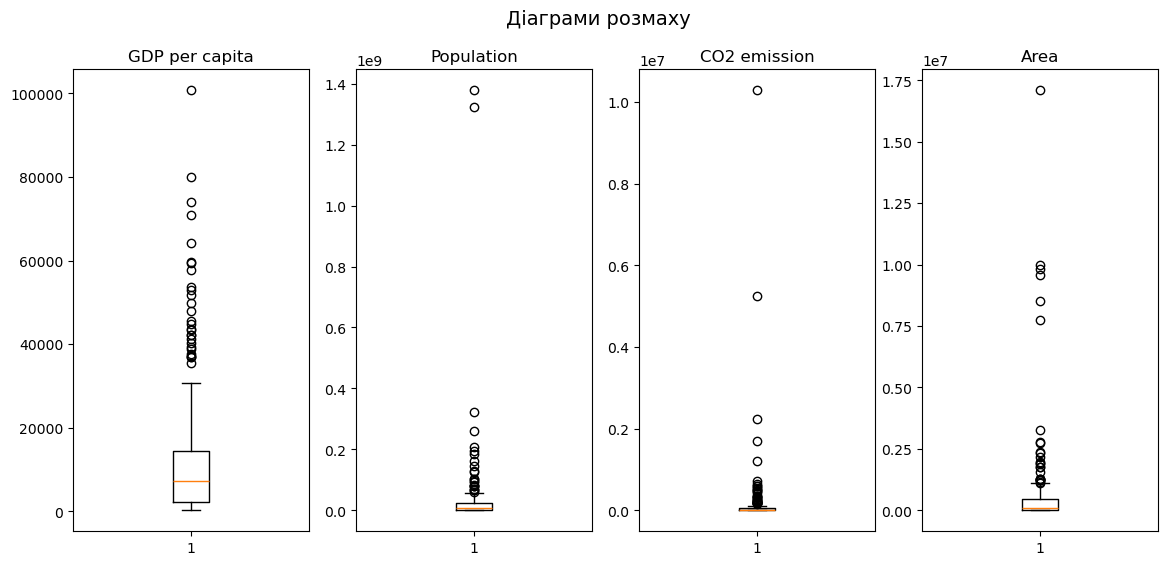

In [189]:
fig, axs = plt.subplots(1, 4, figsize=(14, 6))

fig.suptitle('Діаграми розмаху', fontsize=14)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

<details><summary>Натисніть тут, щоб побачити підказку (використано!)</summary>

```python
# Імпортуємо бібліотеку Matplotlib
import matplotlib.pyplot as plt
    
# діаграми розмаху для "GDP per capita", "Population", "CO2 emission" та "Area"

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

```
</details>




Гістограми:

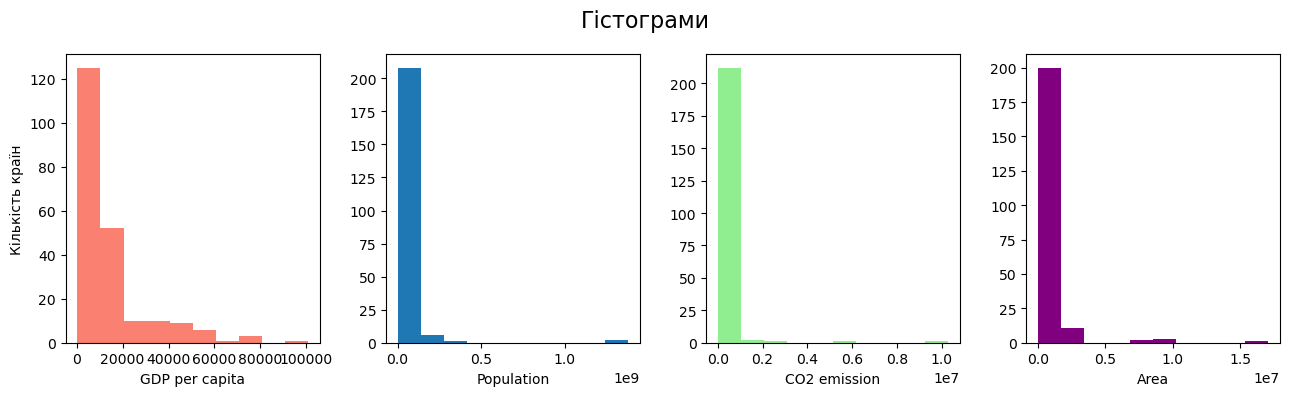

In [215]:
fig, axs = plt.subplots(1, 4, figsize=(13, 4))

fig.suptitle('Гістограми', fontsize=16)

axs[0].set_xlabel('GDP per capita')
axs[0].set_ylabel('Кількість країн')
axs[0].hist(df['GDP per capita'], bins=10, color='salmon')

axs[1].set_xlabel('Population')
axs[1].hist(df['Population'], bins=10)

axs[2].set_xlabel('CO2 emission')
axs[2].hist(df['CO2 emission'], bins=10, color='lightgreen')

axs[3].set_xlabel('Area')
axs[3].hist(df['Area'], bins=10, color='purple')

plt.tight_layout()
plt.show()

<a name="task6"></a>
 <div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. Яка країна має найбільший ВВП на людину (GDP per capita)?
2. Яка країна має найменшу площу?
3. Знайдіть країну з найбільшою щільністю населення у світі? У Європі та центральній Азії?
4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.



<details><summary>Натисніть тут, щоб побачити підказку</summary>
    
Скористайтесь методами <code>loc()</code> для повернення зрізу датафрейму, <code>idxmax()</code> для повернення номера рядка з найбільшим значенням якогось показника у стовпці та <code>idxmin()</code> для повернення номера рядка з найменшим значенням якогось показника у стовпці
    
```python
df.loc[df['GDP per capita'].idxmax()]

```
    
Гарно оформити виведення інформації допоможе <code>print()</code>  
```python
print('\n' + df.loc[df['GDP per capita'].idxmax(), 'Country Name'] + ' має найбільший ВВП на людину')
```   
  
</details>


1. Країна, яка має найбільший ВВП на людину:

In [229]:
df.loc[df['GDP per capita'].idxmax(), 'Country Name']

'Luxembourg'

2. Країна, яка має найменшу площу:

In [235]:
df.loc[df['Area'].idxmin(), 'Country Name']

'Monaco'

3. Країна з найбільшою щільністю населення і частина світу:

In [239]:
df.loc[df['population density'].idxmax(), 'Country Name']

'Macao SAR, China'

Країна з найбільшою щільністю населення в Європі та центральній Азії:

In [252]:
europe_asia_df = df.loc[df['Region'] == 'Europe & Central Asia']
europe_asia_df.loc[europe_asia_df['population density'].idxmax(), 'Country Name']

'Monaco'

4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.

Топ 5 країн:

In [263]:
pd.set_option('display.precision', 2)
df.sort_values(by='GDP per capita', ascending=False).head(5)

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,population density
115,Luxembourg,Europe & Central Asia,100738.68,5.83e+05,9658.88,2590.0,225.09
188,Switzerland,Europe & Central Asia,79887.52,8.37e+06,35305.88,41290.0,202.76
116,"Macao SAR, China",East Asia & Pacific,74017.18,6.12e+05,1283.45,30.3,20203.53
146,Norway,Europe & Central Asia,70868.12,5.23e+06,47627.00,385178.0,13.59
92,Ireland,Europe & Central Asia,64175.44,4.77e+06,34066.43,70280.0,67.92


In [271]:
df.sort_values(by='GDP per capita', ascending=False).tail(5)

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,population density
118,Madagascar,Sub-Saharan Africa,401.74,2.49e+07,3076.61,587295.0,42.39
37,Central African Republic,Sub-Saharan Africa,382.21,4.59e+06,300.69,622980.0,7.38
134,Mozambique,Sub-Saharan Africa,382.07,2.88e+07,8426.77,799380.0,36.06
119,Malawi,Sub-Saharan Africa,300.31,1.81e+07,1276.12,118480.0,152.70
31,Burundi,Sub-Saharan Africa,285.73,1.05e+07,440.04,27830.0,378.16


Збережіть дані у новий файл 'clean_data2.csv':


In [277]:
df.to_csv("data2_new.csv", index=False)

<h2>Виконала студентка групи ІП-23  <br>Матвієнко Дарʼя</h2>
